# Exploratory Data Analysis

## О задании

В этом задании вы получите опыт подготовки данных и EDA (Exploratory Data Analysis), приблизившись к реальной работе с данными с помощью уже знакомых вам инструментов: numpy, pandas, matplotlib и seaborn, а также познакомитесь с plotly.

EDA - важный этап работы с данными. Именно в процессе EDA вы можете выяснить особенности датасета, найти зависимости в данных, протестировать гипотезы о взаимосвязях признаков и целевой переменной. В реальности вы сами будете определять, что и как проверять в рамках EDA, однако в данной работе гипотезы будут выдвинуты за вас автором задания. Также и типы графиков, которые вы будете использовать уже предопределены за вас. Выполняя задания по визуализациям, обращайте внимание на референсные картинки, которые были оставлены автором. Они показывают, какой примерно результат от вас ожидается.

Это задание будет включать в себя построение некоторого количества графиков, потому вот основные правила, в соответствии с которыми графики должны быть оформлены:
1. Любой график всегда имеет название.
2. Оси у графика подписаны (исключение - график делит название оси с соседним).
3. Подписи делаются на одном языке (либо английский, либо русский), но не на их смеси.
4. Если вы выводите несколько графиков, то они размещаются в рамках одного объекта matplotlib.pyplot.figure. Вы не выводите графики последовательно, а смотрите, как их разместить сразу все за раз.
5. Отдельные графики (если графиков на картинке больше 1) также имеют свои названия.
6. Если на графике есть несколько различных объектов, то для их различения используется легенда. Помещайте легенду в место, где она в наименьшей мере мешает восприятию самого графика.
7. Если есть легенда, то она должна иметь навание, а также ее содержание должно быть адекватными (пожалейте проверяющих, они не хотят разбирать, а к чему относится зеленая линия, которая на легенде помечена меткой "0").
8. Используйте цветовые гаммы, чтобы объекты на графиках отличались цветом.
9. Текст на визуализации должен быть читаем. Если вы вывели названия категорий в качестве подписей на оси Х, а эти названия наезжают друг на друга, то вам нужно что-то с этим сделать. Нечитаемый или плохо читаемый (очень маленький, невероятно огромный) текст ведет к снижению баллов.

## О данных

Будем работать с [датасетом физической активности](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones).

В этом датасете собраны данные 30 человек, выполняющих различные действия со смартфоном на поясе. Данные записывались с помощью датчиков (акселерометра и гироскопа) в этом смартфоне. Были зафиксированы: "3-осевое линейное ускорение" (_tAcc-XYZ_) и "3-осевая угловая скорость" (_tGyro-XYZ_).

1. Все сигналы отсортированы по времени, пропущены через фильтр шума.
2. Все наблюдения были разделены на окна по 128 сигналов в каждом, причем окна пересекаются на 50% (грубо говоря, с 1 по 128 сигнал в 1 окно, с 64 до 192 сигнала - во 2 окно и так далее).
3. Линейное ускорение было разделено на две составляющие (с помощью низкочастотного фильтра): ускорение самого тела, а также гравитационная составляющая. Будем называть их ускорением тела и гравитационным ускорением.
4. К получившимся окнам применяли различные функции для получения следующих показателей:
    - max
    - min
    - mad (median)
    - mean
    - std
    - skewness (коэффициент асимметричности распределения признака в окне)
    - etc. (подробнее, на сколько это возможно, указано на [страничке датасета](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones))
5. Величина (magnitude) сигнала также определялась через евклидову норму всех значений из вектора для одного окна.
6. К окнам было применено преобразование Фурье, чтобы получить частоты. Из частот были извелчены те же показатели, плюс новые:
    - bandsEnergy (энергия частотного интервала)
7. Были посчитаны углы между векторами соответствующих окон.
8. Для ускорений были посчитаны производные - рывки, к которым применялись те же функции.

Итог: в датасете каждый признак - это какая-то операция над вектором из 128 чисел, которые соответствуют замерам определенного человека занятого какой-то активностью на протяжении 2.56 секунд.

Как читать названия признаков? Примеры:
- `tBodyAccMag-mean()` - это вектор ускорений тела (без гравитационной составляющей этого ускорения), из которого взяли евклидову норму, а затем усреднили, чтобы получить скаляр
- `fBodyAcc-bandsEnergy()-1,8.2` - это вектор ускорения тела, к которому применили преобразование Фурье, преобразовав его в вектор частот, а затем посчитали на этом векторе энергию данного частотного интервала в определенном диапазоне частот (в данном случае 1 - 8.2)
- `angle(X,gravityMean)` - это угол между осью Х и вектором усредненных значений гравитационного ускорения из соответствующего окна

Вероятно, сначала покажется сложным, но мы разберемся с некоторыми признаками в отдельности и вы сможете понять их смысл, уже исходя из фактических соотношений.

## Предобработка данных

In [1]:
!kaggle datasets download -d uciml/human-activity-recognition-with-smartphones
!unzip human-activity-recognition-with-smartphones.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones
License(s): CC0-1.0
 94% 23.0M/24.5M [00:00<00:00, 92.3MB/s]
100% 24.5M/24.5M [00:00<00:00, 84.1MB/s]
Archive:  human-activity-recognition-with-smartphones.zip
  inflating: test.csv                
  inflating: train.csv               


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv("test.csv")

In [4]:
train.shape

(7352, 563)

В датасете 563 признака, включая целевую переменную. Столько признаков нам не нужно. Мы за вас сделали подвыборку признаков для удобства работы с ними.

In [5]:
cols_subset = [
    'tBodyAccMag-mean()',  # усредненная величина ускорения тела
    'tBodyGyroJerk-mad()-X',  # медианная величина рывка тела по оси Х
    'tGravityAcc-min()-X',  # минимум гравитационной составляющей ускорения по оси Х
    'tBodyAcc-max()-X',  # максимальная величина ускорения тела по оси Х
    'fBodyAcc-bandsEnergy()-1,8.2',  # энергия ускорения тела в интервале частоты
    'angle(X,gravityMean)',  # угол между осью Х и усредненной гравитационной составляющей ускорения
    'angle(Y,gravityMean)',  # угол между осью Y и усредненной гравитационной составляющей ускорения
    'angle(Z,gravityMean)',  # угол между осью Z и усредненной гравитационной составляющей ускорения,
    'fBodyAcc-skewness()-X',  # асимметричность частоты ускорения тела по оси Х
    'subject',  # номер испытуемого
    'Activity',  # название вида деятельности (целевая переменная)
]

In [6]:
train = train[cols_subset]
test = test[cols_subset]

### Задание 1

Посмотрите на пропуски и дубли в данных train и test. Есть ли они? Если есть, напишите, с чем это может быть связано? Если нет, то просто напишите, что пропусков и/или дублей нет.

In [7]:
print(train.isnull().sum())
print(train.duplicated().sum())

tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64
0


In [8]:
print(test.isnull().sum())
print(test.duplicated().sum())

tBodyAccMag-mean()              0
tBodyGyroJerk-mad()-X           0
tGravityAcc-min()-X             0
tBodyAcc-max()-X                0
fBodyAcc-bandsEnergy()-1,8.2    0
angle(X,gravityMean)            0
angle(Y,gravityMean)            0
angle(Z,gravityMean)            0
fBodyAcc-skewness()-X           0
subject                         0
Activity                        0
dtype: int64
0


Очевидно, пропусков нет

### Задание 2

Выведите основные статистики данных: среднее, медиана, перцентили (0.25, 0.5, 0.75), минимум, максимум, стандартное отклонение. Посмотрите на таблицу и напишите, видите ли вы в ней что-нибудь интересное.

In [9]:
print(train.describe())

       tBodyAccMag-mean()  tBodyGyroJerk-mad()-X  tGravityAcc-min()-X  \
count         7352.000000            7352.000000          7352.000000   
mean            -0.543884              -0.727735             0.678505   
std              0.477653               0.315832             0.508656   
min             -1.000000              -0.999889            -1.000000   
25%             -0.983282              -0.991595             0.804270   
50%             -0.883371              -0.950268             0.926693   
75%             -0.106892              -0.474625             0.965095   
max              1.000000               1.000000             1.000000   

       tBodyAcc-max()-X  fBodyAcc-bandsEnergy()-1,8.2  angle(X,gravityMean)  \
count       7352.000000                   7352.000000           7352.000000   
mean          -0.468604                     -0.847963             -0.489547   
std            0.544547                      0.233633              0.511807   
min           -1.000000   

In [10]:
print(test.describe())

       tBodyAccMag-mean()  tBodyGyroJerk-mad()-X  tGravityAcc-min()-X  \
count         2947.000000            2947.000000          2947.000000   
mean            -0.559043              -0.735661             0.696878   
std              0.439539               0.282074             0.502873   
min             -0.998936              -1.000000            -0.756774   
25%             -0.978433              -0.989078             0.836787   
50%             -0.861830              -0.914698             0.934930   
75%             -0.149596              -0.486423             0.970871   
max              0.479547               0.117606             0.996148   

       tBodyAcc-max()-X  fBodyAcc-bandsEnergy()-1,8.2  angle(X,gravityMean)  \
count       2947.000000                   2947.000000           2947.000000   
mean          -0.462063                     -0.880361             -0.513923   
std            0.523916                      0.160496              0.509205   
min           -0.952357   

Средние и медиана признаков в тренировочной выборки очень похожи на таковые в тестовой, значит выборки разделены хорошо. Однако с выбросами и распределением данных у некоторых признаков все очень плохо. Например fBodyAcc-bandsEnergy()-1,8.2 имеет среднее очень близкое к минимуму, а медиану и вовсе практически равную минимуму, что означает наличие сильных выбросов в положительную сторону. Похожая ситуация у tBodyGyroJerk-mad()-X и angle(X,gravityMean), очевидно мы имеем какие-то сдвиги и скосы по оси X. В то же время по оси Z данные очень спокойные и ровные, что в принципе справедливо для человеческих движений.

### Задание 3

Данные сбалансированы? У вас есть 6 категорий активности (целевая переменная). Если одна из категорий представлена большим количеством наблюдений, а остальные - нет, то это обстоятельство, о котором хотелось бы знать заранее. Гиперболизированный пример: представьте, что у вас 1000 наблюдений, разделенных на два класса, и только 5 принадлежат ко второму классу. Как учить модель на такой выборке? Есть сильное подозрение, что многие модели будут склонны вырождаться в константу. Отсюда и необходимость проверять баланс классов.

Выведите количество наблюдений для всех категорий активности в train и test. Посчитайте разницу в процентах между самой крупной категорией и самой маленькой (самая большая категория - это 100%). Если разница (округленная до ближайшего целого числа) не превышает 30%, то давайте для наших целей считать, что данные сбалансированы. Напишите, сбалансированы ли данные в train и test.

In [11]:
largest_train = train['Activity'].value_counts().max()
smallest_train = train['Activity'].value_counts().min()

print('Баланс в train:', ((largest_train - smallest_train) / largest_train * 100))

largest_test = test['Activity'].value_counts().max()
smallest_test = test['Activity'].value_counts().min()

print('Баланс в test:', ((largest_test - smallest_test) / largest_test * 100))

Баланс в train: 29.92181947405828
Баланс в test: 21.787709497206702


Разница действительно не превосходит 30%, наши данные сбалансированы.

### Задание 4

Посчитайте корреляции всех признаков со всеми другими. Какими получились значения? Есть идеи, почему так? Напишите ваши мысли.

In [12]:
print(train.corr(numeric_only=True))

                              tBodyAccMag-mean()  tBodyGyroJerk-mad()-X  \
tBodyAccMag-mean()                      1.000000               0.899080   
tBodyGyroJerk-mad()-X                   0.899080               1.000000   
tGravityAcc-min()-X                     0.369962               0.380118   
tBodyAcc-max()-X                        0.959827               0.879900   
fBodyAcc-bandsEnergy()-1,8.2            0.697832               0.507939   
angle(X,gravityMean)                   -0.370849              -0.382246   
angle(Y,gravityMean)                    0.495561               0.478567   
angle(Z,gravityMean)                    0.426283               0.380967   
fBodyAcc-skewness()-X                   0.379796               0.266002   
subject                                -0.073652              -0.110321   

                              tGravityAcc-min()-X  tBodyAcc-max()-X  \
tBodyAccMag-mean()                       0.369962          0.959827   
tBodyGyroJerk-mad()-X           

Видна сильная корреляция всех переменных, содеражщих в названии Х, друг с другом. Очевидно, это потому что они все измеряют что-то относительно одной оси.

Поздравляем! Вы предобработали данные для максимально комфортного их последующего анализа. Теперь вы готовы приступить к Exploratory Data Analysis!

## Exploratory Data Analysis

### Задание 5

Вы проверили основную информацию о данных и составили свое первое впечатление о них. Теперь визуализации.

Начнем рисовать графики с небольшой разминки. Выберите две любые математические функции (отличные от линейной) и нарисуйте их на одном графике. Подпишите каждый из графиков, чтобы было понятно, какие функции вы выбрали.

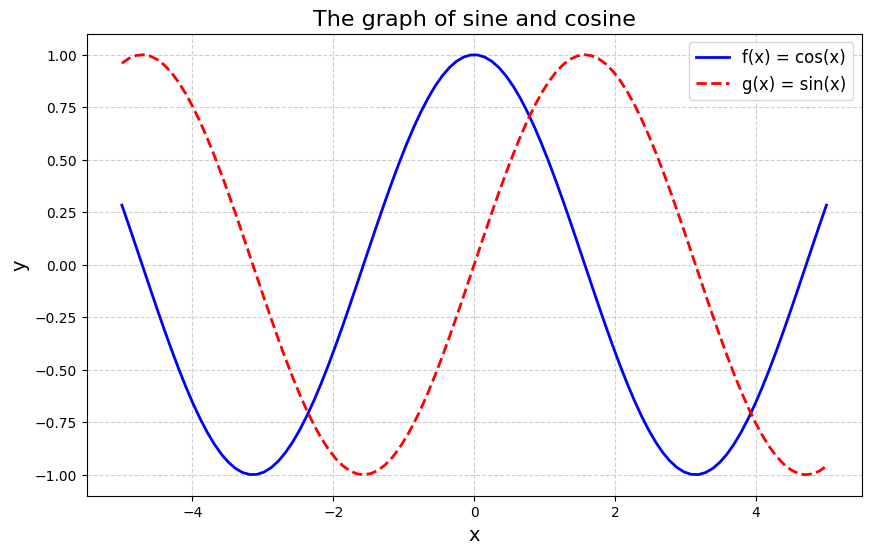

In [13]:
x = np.linspace(-5, 5, 100)

y1 = np.cos(x)
y2 = np.sin(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y1, label='f(x) = cos(x)', color='blue', linewidth=2)
plt.plot(x, y2, label='g(x) = sin(x)', color='red', linestyle='--', linewidth=2)

plt.title('The graph of sine and cosine', fontsize=16)
plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)

plt.legend(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Задание 6

Ранее мы уже проверили сбалансированность данных по разным категориям активностей в train и test сетах. Теперь визуализируйте количество сэмплов в каждой из категорий отдельно для train и test сетов, как в примере ниже. Проследите, чтобы порядок категорий слева и справа был одинаков. Иначе не очень удобно их сравнивать (когда они в разных местах двух графиков). Также заметьте, что в примере ось Х в одинаковом масштабе, что тоже удобно для сравнения.

Вам может пригодиться:
- plt.barh или ax.barh

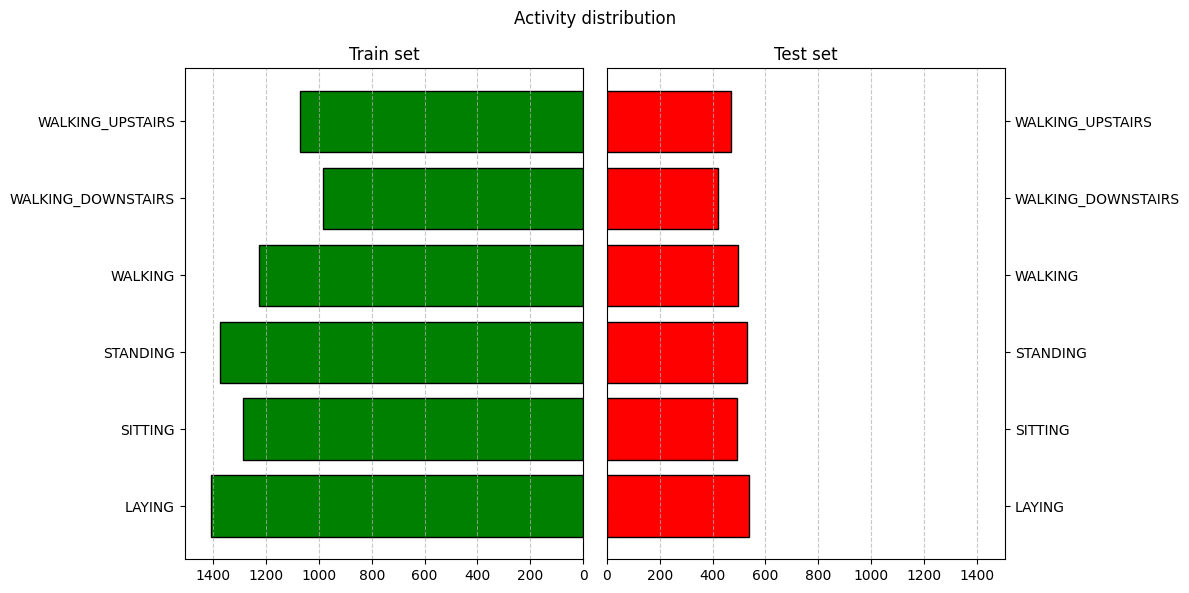

In [14]:
train_counts = train['Activity'].value_counts().sort_index()
test_counts = test['Activity'].value_counts().sort_index()

categories = train_counts.index

fig, axes = plt.subplots(1, 2, figsize=(12, 6), )

axes[0].barh(categories, train_counts, color='green', edgecolor='black')
axes[0].invert_xaxis()
axes[0].set_title('Train set')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

axes[1].barh(categories, test_counts, color='red', edgecolor='black')
axes[1].set_title('Test set')
axes[1].yaxis.tick_right()
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

max_count = max(train_counts.max(), test_counts.max())
axes[0].set_xlim(max_count+100, 0)  # Инвертированный масштаб для train
axes[1].set_xlim(0, max_count+100)

fig.suptitle('Activity distribution')
plt.tight_layout()
plt.show()

Правда на таких графиках проще проверять баланс классов таргета?)

### Задание 7

Ранее вы выводили таблицу корреляций. Однако просто таблица корреляций не очень удобна для анализа. Что, если признаков было бы больше? Визуализируйте heatmap корреляций. Подпишите значения корреляций, округленные до 2 знаков после запятой, на графике и оставьте только те значения, которые по модулю не меньше 0.5. Будем считать такие корреляции существенными.

Какой признак стоит исключить из рассмотрения корреляций? Напишите его название, а также причину, почему нет смысла его рассматривать.

Вам может пригодиться:
- sns.heatmap
- методы get_text и set_text у атрибута texts графика

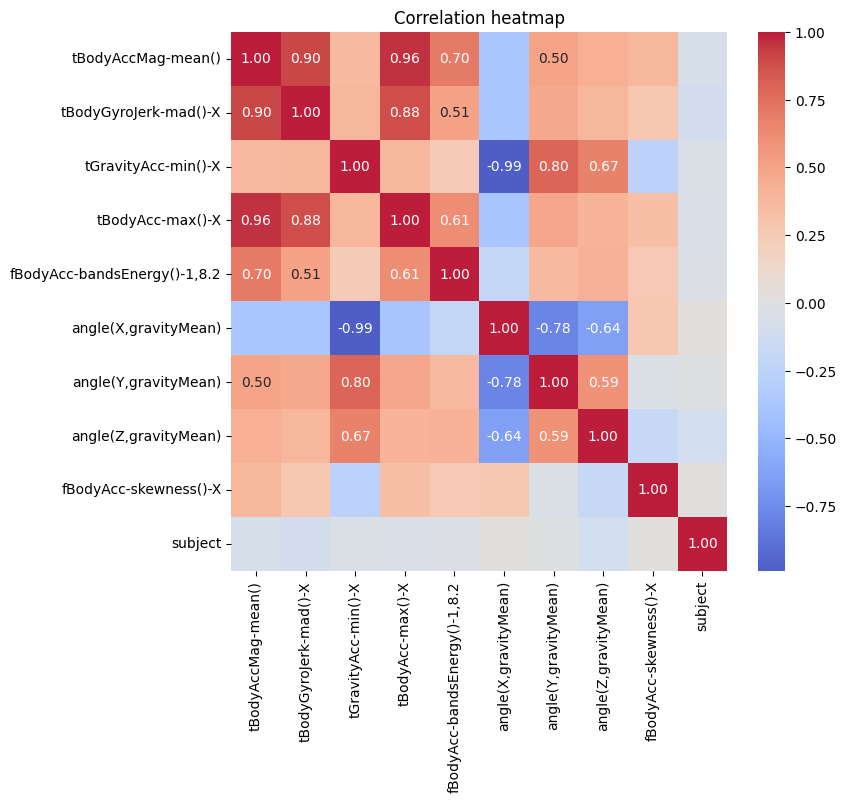

In [15]:
corr_info = train.corr(numeric_only=True)

plt.figure(figsize=(8, 7))

ax = sns.heatmap(corr_info, cmap='coolwarm', alpha=0.9, annot=True, fmt='.2f')

for text in ax.texts:
    # Получаем текущее значение текста
    value = float(text.get_text())

    # Если модуль значения меньше 0.5, заменяем его на пустую строку
    if abs(value) < 0.5:
        text.set_text("")  # Убираем текст

plt.title('Correlation heatmap')
plt.show()

Subject бессмысленно анализировать, так как это всего лишь номер испытуемого, не имеющий ни смысла, ни порядка, это просто идентификатор

### Задание 8

Для начала будем стрелять из пушки по воробьям. Выведите pairplot по всем данным train сета. Напишите, заметили ли вы в нем что-нибудь интересное, чего не было в таблицах и графиках ранее, а также сообщите, было ли вам удобно анализировать 100 графиков.

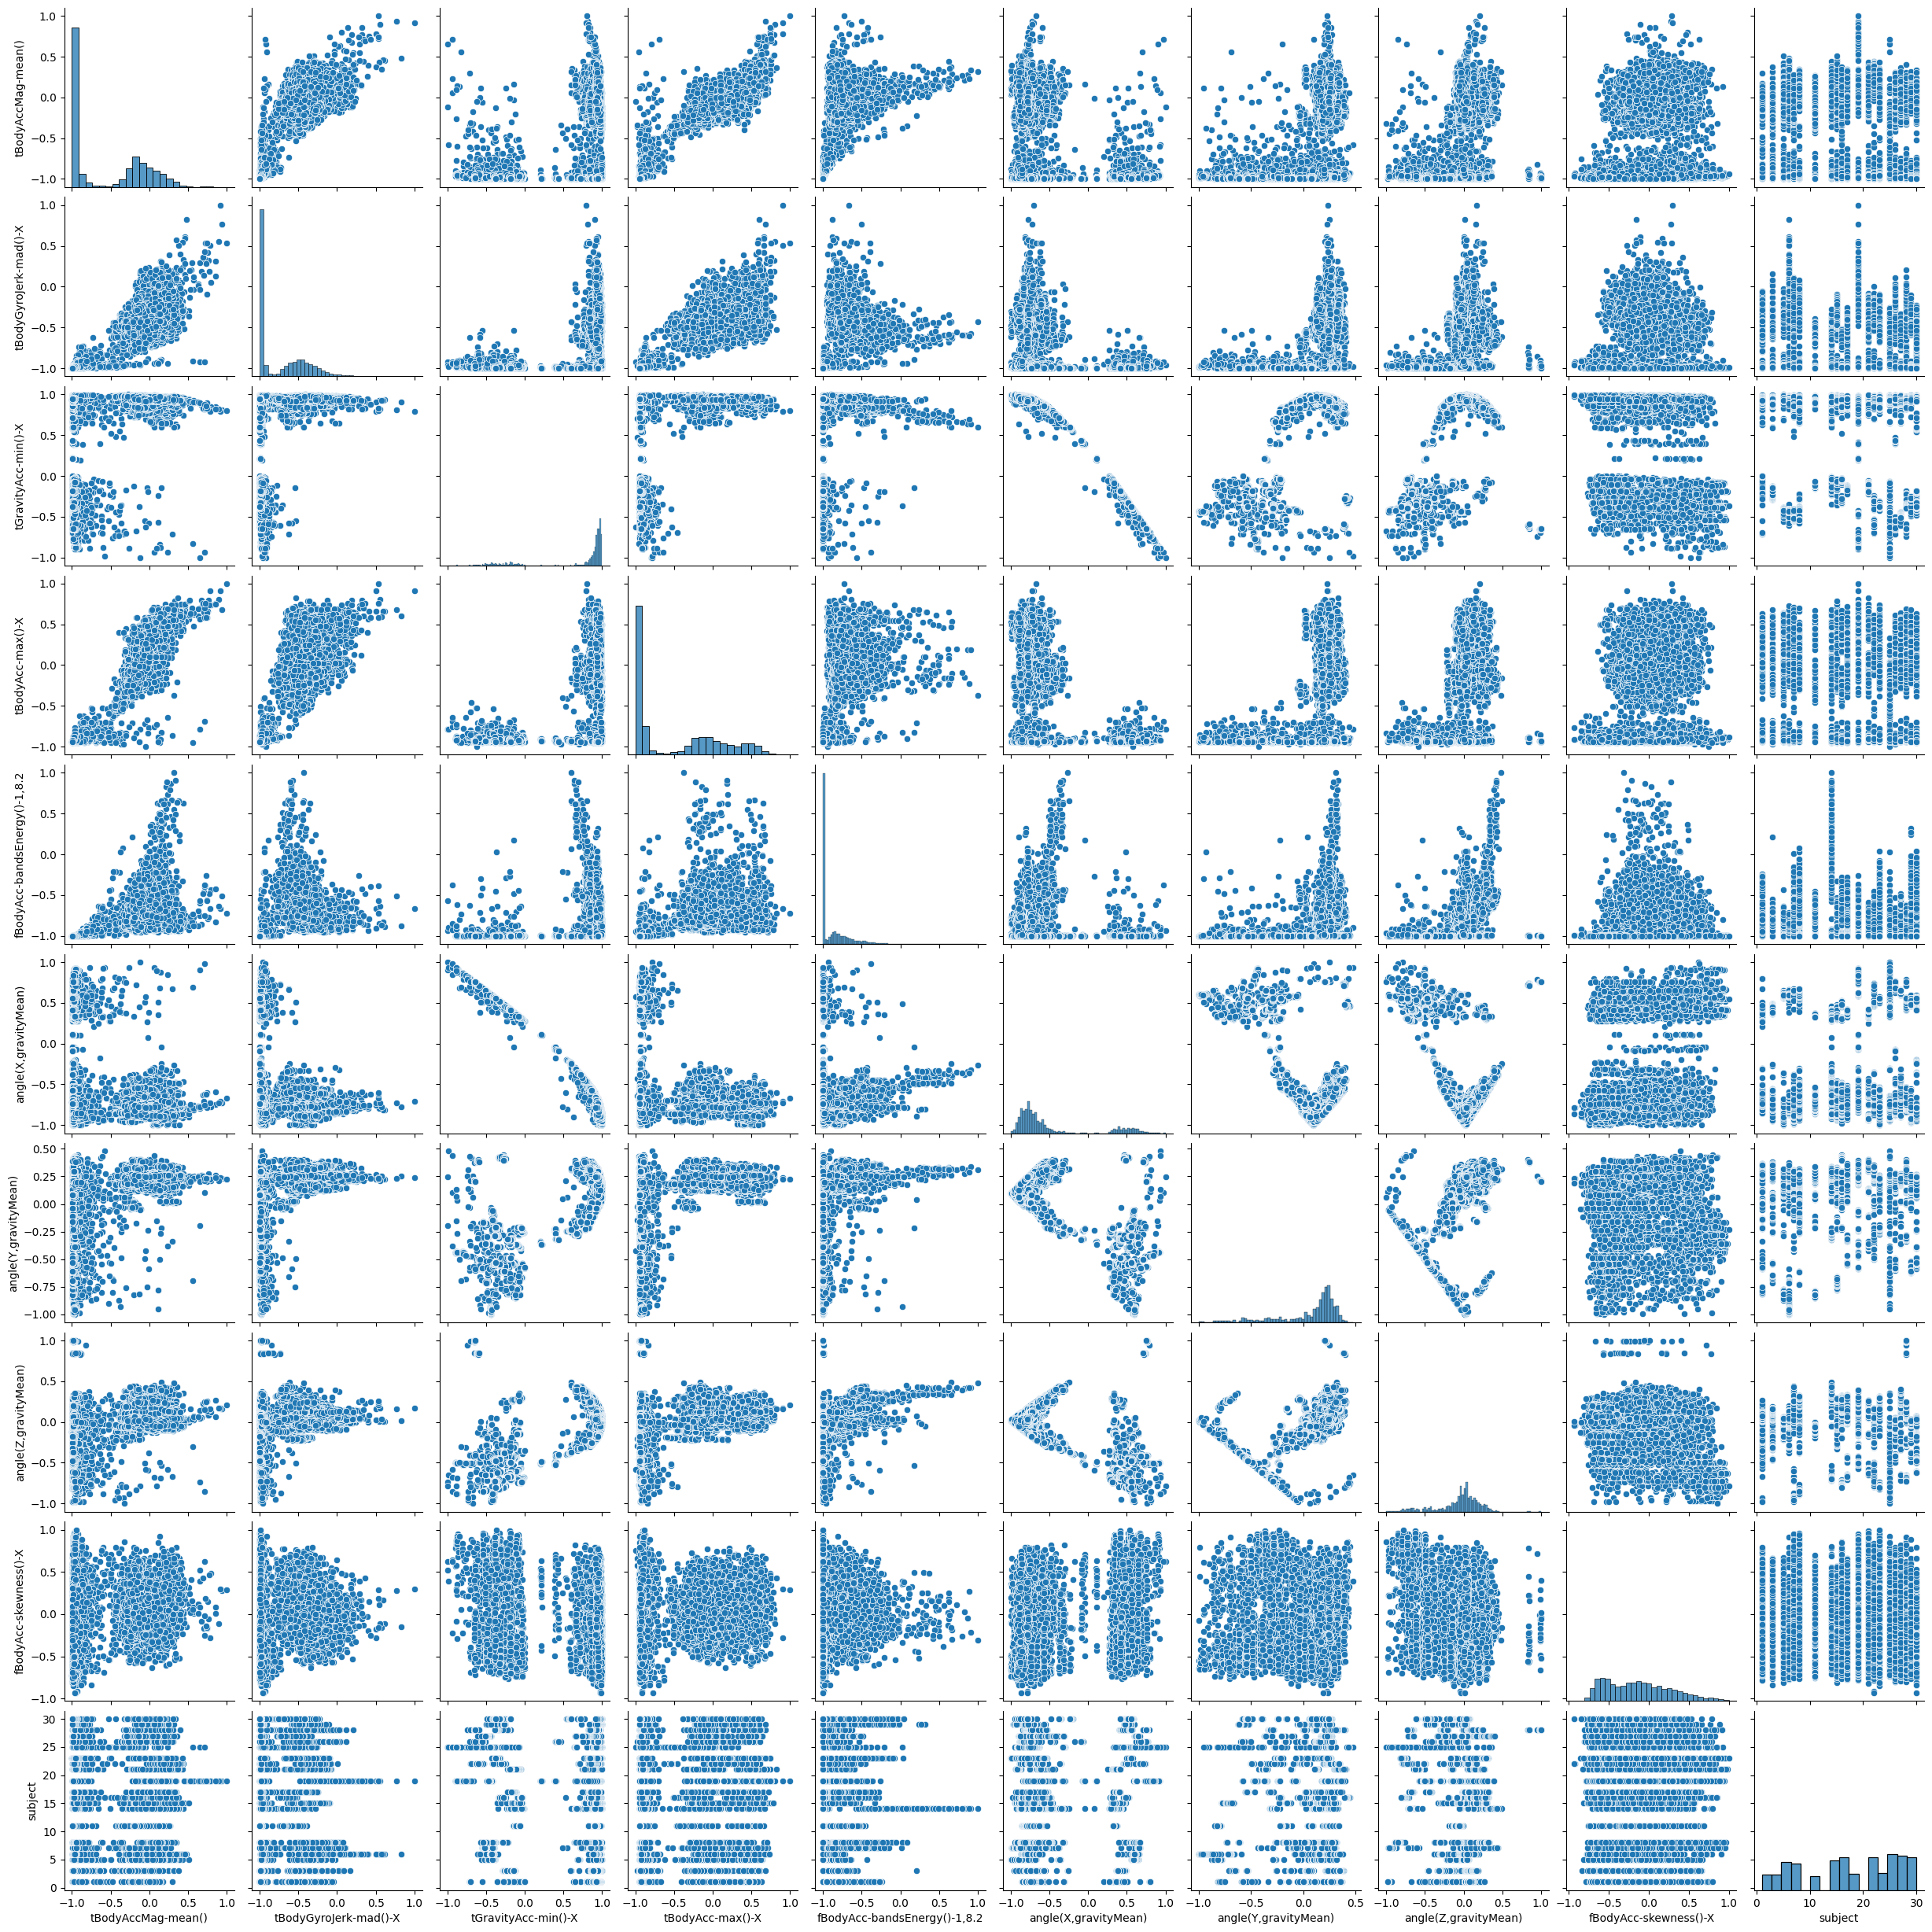

In [16]:
sns.pairplot(train)

plt.show()

Анализировать не слишком удобно

### Задание 9

Окей. Смотреть на все сразу не очень удобно. Кажется, нужно смотреть на признаки в отдельности и искать в них инсайты.

Попробуем проверить гипотезу. Отобразите плотность распределения (kde) `tBodyAccMag-mean()` (усредненная величина ускорения тела) для каждой из активностей, как в примере ниже. Видите закономерность? Можно ли поделить все активности на две группы? Если да, то проведите вертикальную линию, которая визуально неплохо разделяет эти группы.

Давайте первую группу называть статическими активностями, а вторую - динамическими.

Посчитайте, какую долю правильных ответов дает ваша вертикальная линия для разделения именно этих двух групп. С чем может быть связан полученный вами результат? Предположите логическое обоснование (почему именно данный признак так хорошо/плохо разделяет группы активностей).

Вам может пригодиться:
- sns.kdeplot

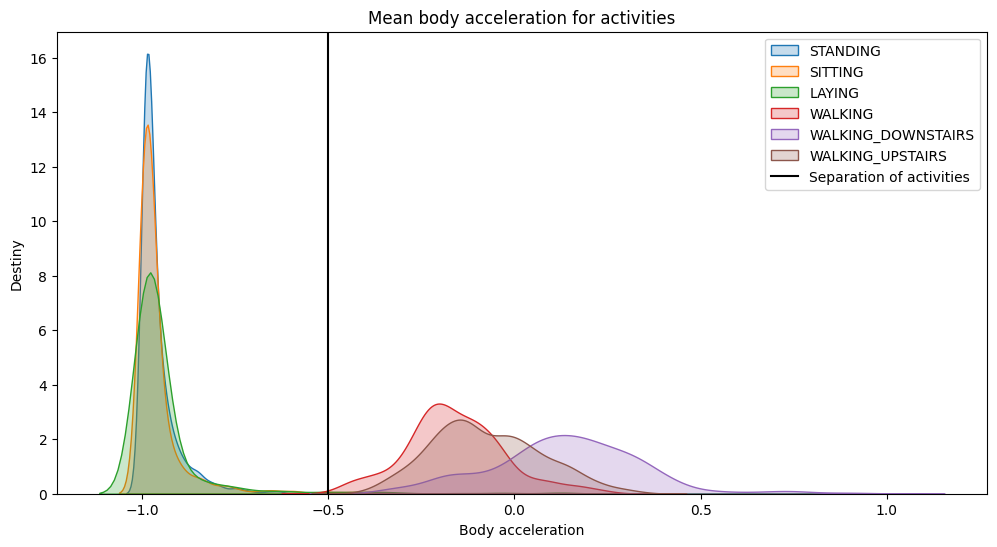

In [17]:
plt.figure(figsize=(12, 6))

for activity in train.Activity.unique():
  subset = train[train.Activity == activity]
  sns.kdeplot(subset['tBodyAccMag-mean()'], label=activity, shade=True)

plt.title('Mean body acceleration for activities')
plt.xlabel('Body acceleration')
plt.ylabel('Destiny')
plt.legend(title='Activity')

plt.axvline(x=-0.5, color='black', label='Separation of activities')
plt.legend()

plt.show()

In [18]:
static_activities = ['LAYING', 'SITTING', 'STANDING']
dynamic_activities = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

train['Predicted_Group'] = train['tBodyAccMag-mean()'].apply(lambda x: 'Static' if x < -0.5 else 'Dynamic')

train['True_Group'] = train['Activity'].apply(lambda x: 'Static' if x in static_activities else 'Dynamic')

correct_predictions = (train['Predicted_Group'] == train['True_Group']).sum()
total_samples = len(train)
accuracy = correct_predictions / total_samples

print(f"Доля правильных ответов: {accuracy:.2%}")

train.drop(['Predicted_Group', 'True_Group'], axis=1, inplace=True)

Доля правильных ответов: 99.22%


Признак tBodyAccMag-mean() представляет собой среднее значение величины ускорения тела. Для статических активностей (лежание, сидение, стояние) ускорение обычно близко к нулю или слегка отрицательно, так как движения минимальны. Для динамических активностей (ходьба, бег, подъем по лестнице) ускорение значительно выше из-за активных движений.

### Задание 10

Поздравляем, вы проверили первую гипотезу в процессе EDA. Однако нам бы хотелось уметь не группы разделять, а каждый отдельный вид активности. Попробуйте нарисовать "ящики с усами" для `angle(X,gravityMean)` (угол между осью Х и усредненной гравитационной составляющей ускорения) с разделением по разным видам активности на данных train. Можно ли сделать какой-то вывод по полученной визуализации? Проанализируйте и проинтерпретируйте полученные картинки (если заметили какую-то особенность, может какая-то категория значительно выделяется, то предположите, почему так могло произойти).

Вам может пригодиться:
- sns.boxplot

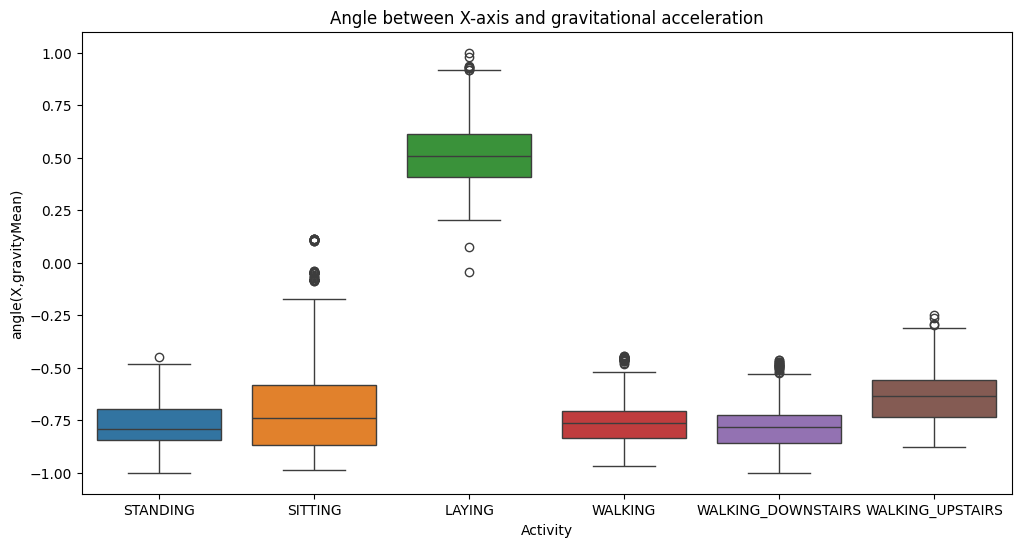

In [19]:
plt.figure(figsize=(12, 6))

sns.boxplot(x='Activity', y='angle(X,gravityMean)', data=train, palette='tab10')

plt.title('Angle between X-axis and gravitational acceleration')

plt.show()

Лежание значительно выделяется так как предполагает горизонтальную ориентацию тела (соответственно максимальный угол), а все остальные вертикальную. Большой разброс данных у сидения, так как сидеть можно по-разному и угол относительно горизонта будет меняться. Ходьба вверх немного выделяется из-за перемещения в двух осях.

### Задание 11

Посмотрим теперь на `tBodyAcc-max()-X` (максимальная величина ускорения тела по оси Х). Визуализируйте скрипичные диаграммы для этого признака с разделением по активностям на всем train. Кажется логичным, что максимальное ускорение в моменте для разных активностей будет различаться. Однако есть ли активность, которая будет выделяться? Если да, то предложите объяснение, почему эта активность выделяется.

Вам может пригодиться:
- sns.violinplot

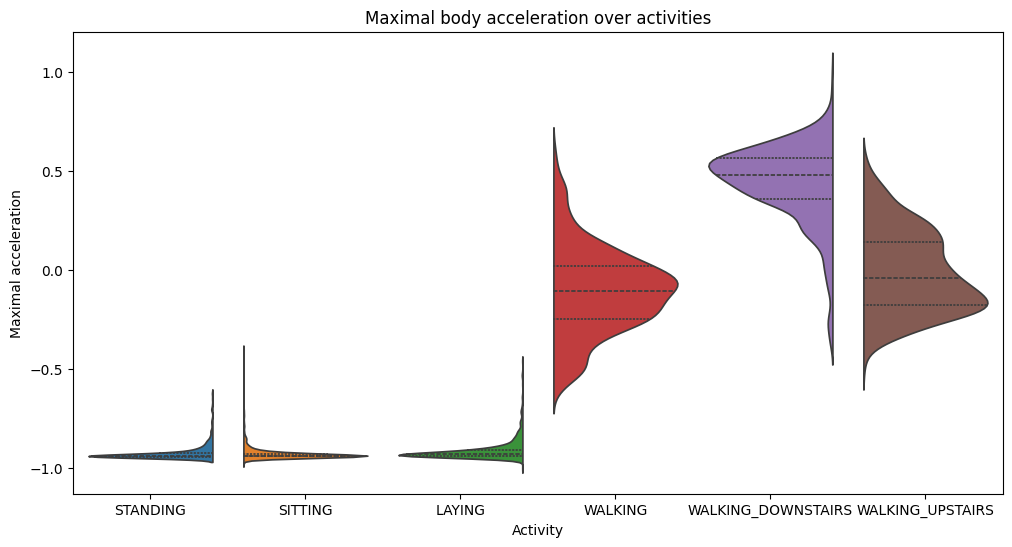

In [20]:
plt.figure(figsize=(12, 6))

sns.violinplot(x='Activity', y='tBodyAcc-max()-X', data=train, palette='tab10', split=True, inner='quart')

plt.title('Maximal body acceleration over activities')
plt.ylabel('Maximal acceleration')

plt.show()

Можно сказать что выделяется спуск вниз, так как он предполагает самую быструю скорость движения, ибо это банально проще.

### Задание 12

Вы уже можете с довольно хорошим качеством выделить две категории активности из шести. Продолжим.

Ранее уже упоминалось разделение на две группы активностей: статические и динамические. Пришла пора разделить датасет train на две части. Сделайте это! Теперь на одной картинке покажите распределения `fBodyAcc-bandsEnergy()-1,8.2` (энергия ускорения тела в интервале частоты) для динамичных активностей (boxenplot - немного измененый "ящик с усами") и `angle(Y,gravityMean)` (угол между осью Y и усредненной гравитационной составляющей ускорения) для статических - тут хватит и простой гистограммы (прямо, как в примере ниже). Можно ли выделить еще какие-то активности? Если да, напишите, какие активности на 1 и 2 графиках выделяются.

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec (заметили, что один график больше другого? попробуйте сами так сделать - вам понравится...)
- sns.boxenplot
- sns.histplot

In [23]:
static_activities = ['LAYING', 'SITTING', 'STANDING']
dynamic_activities = ['WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']

static_data = train[train['Activity'].isin(static_activities)]
dynamic_data = train[train['Activity'].isin(dynamic_activities)]

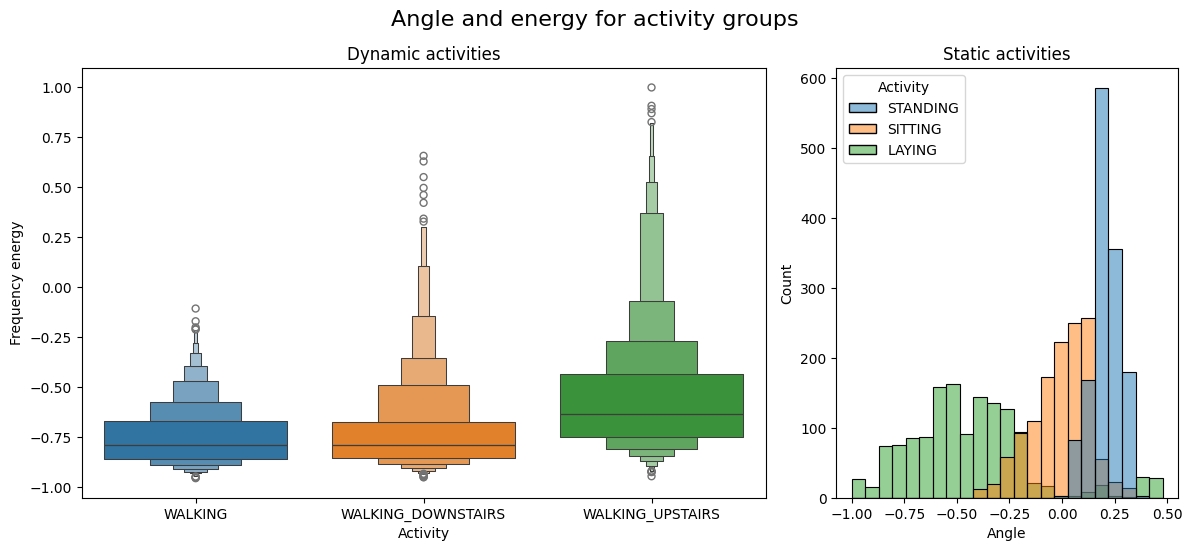

In [58]:
from matplotlib import gridspec

plt.figure(figsize=(12, 14))
gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1], height_ratios=[1, 2])

ax1 = plt.subplot(gs[0, 0])
sns.boxenplot(x='Activity', y='fBodyAcc-bandsEnergy()-1,8.2', data=dynamic_data, palette='tab10', ax=ax1)
ax1.set_title('Dynamic activities')
ax1.set_ylabel('Frequency energy')

ax2 = plt.subplot(gs[0, 1])
sns.histplot(x='angle(Y,gravityMean)', data=static_data, palette='tab10', ax=ax2, hue='Activity')
ax2.set_title('Static activities')
ax2.set_xlabel('Angle')

plt.tight_layout()
plt.suptitle('Angle and energy for activity groups', y=1.015, fontsize=16)
plt.show()

Логично, что ходьба вверх более энергозатратна, чем обычная. Так же логично, что когда стоишь, твое ускорение по Y будет иметь угол с гравитацией, а когда лежишь такой угол будет минимальным.

### Задание 13

Не всегда жизнь будет такой легкой, а данные будут полностью или почти линейно разделимы в одному признаку (иначе чем бы занимались дата саентисты...). Часто данные вообще ни по одному признаку нельзя адекватно разделить (да и по комбинациям признаков тоже). Давайте попробуем взять не один признак, а целых два!

Рассмотрим только статические активности. Будет снова два графика сразу. На первом графике будет боксплот распределения `fBodyAcc-skewness()-X` (асимметричность частоты ускорения тела по оси Х) по активностям. А на втором попробуем взять не все наблюдения данной группы активностей, а только их часть. Разделимы ли категории по `fBodyAcc-skewness()-X`? А если взять только те строки, где `fBodyAcc-skewness()-X < -0.376`, и теперь вывести боксплот распределения `angle(Y,gravityMean)` по разным активностям? Попробуйте и напишите, выделилась ли какая-то категория?

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.boxplot

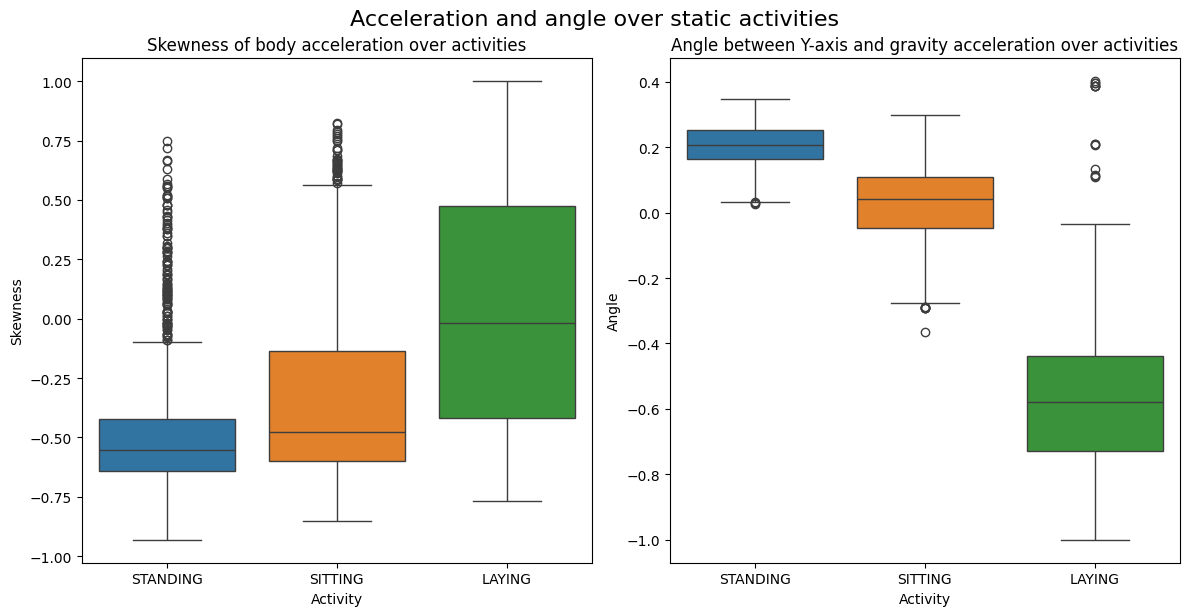

In [68]:
fig = plt.figure(figsize=(12, 6))

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0])
sns.boxplot(x='Activity', y='fBodyAcc-skewness()-X', data=static_data, palette='tab10', ax=ax1)
ax1.set_ylabel('Skewness')
ax1.set_title('Skewness of body acceleration over activities')

ax2 = fig.add_subplot(gs[1])
sns.boxplot(x='Activity', y='angle(Y,gravityMean)', data=static_data[static_data['fBodyAcc-skewness()-X'] < -0.376],
            palette='tab10', ax=ax2)
ax2.set_ylabel('Angle')
ax2.set_title('Angle between Y-axis and gravity acceleration over activities')

plt.tight_layout()
plt.suptitle('Acceleration and angle over static activities', y=1.02, fontsize=16)
plt.show()

Асимметричность частоты ускорения тела по оси Х действительно не дает нам линейно разделить данные. Все три категории захватывают весь диапазон значений, причем лежание захватывает целиком, а стояние захватываает выбросами.

Но если отфильтровать по порогу и взглянуть на угол между Y и ускорением, то ситуация становится получше. Можно сказать, что у лежания большой отрицательный угол, у сидения он околонулевой, а у стояния он положительный. стоит отметить, что хвосты распределений по-прежнему перекрываются.

Поздравляем, теперь вы на шажок ближе к тому, чтобы стать решающим деревом!

### Задание 14

Вот и осталась лишь одна активность, которую мы никак не выделили. Попробуем и ее какими-то порогами отделить от всех остальных. Да, можно было бы сказать, что, раз уж мы выделили 5 из 6 категорий, то все остальное - это и есть последняя категория, но мы не идем легкими путями. Выделить оставшуюсь категорию с хорошим качеством не так уж и просто. Из доступных признаков, сначала посмотрите на распределение `tBodyAcc-max()-X` (максимальная величина ускорения тела по оси Х) на динамических активностях (скрипичная диаграмма отлично подойдет).

А теперь спускаем вам порог `tBodyAcc-max()-X < 0.157`. Для таких строк постройте диаграмму рассеяния для признака `tGravityAcc-min()-X` (минимум гравитационной составляющей ускорения по оси Х). Да, получается неидеально, но это честная работа. Можно выбрать порог так, чтобы чисто из таблицы с динамическими активностями из строк, где `tBodyAcc-max()-X < 0.157`, выбрать по некоторому порогу для `tGravityAcc-min()-X` строки так, чтобы доля правильных ответов на оставшейся категории была не меньше 79%!

Вам может пригодиться:
- plt.subplots или matplotlib.gridspec
- sns.violinplot
- sns.swarmplot (иногда лучше подходит, чем просто sns.scatterplot)

Обратите внимание, что подписи к осям можно убирать методами plt. Например, если у вас общее название для оси Y для обоих графиков, то можно не подписывать ось Y у второго графика.

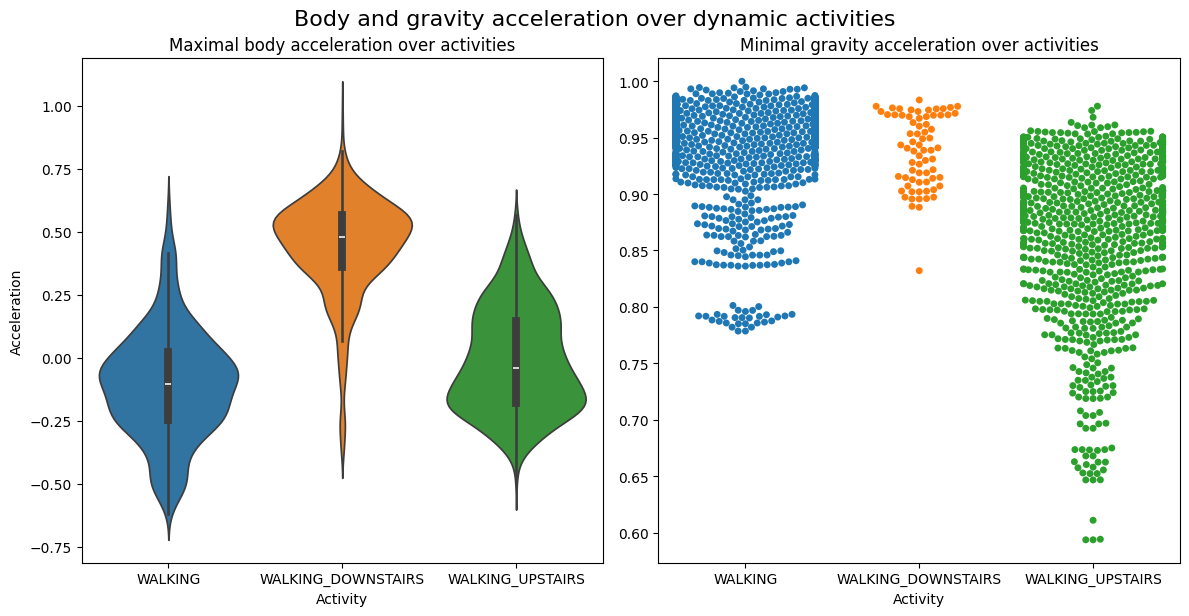

In [72]:
fig = plt.figure(figsize=(12, 6))

gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

ax1 = fig.add_subplot(gs[0])
sns.violinplot(x='Activity', y='tBodyAcc-max()-X', data=dynamic_data, palette='tab10', ax=ax1)
ax1.set_ylabel('Acceleration')
ax1.set_title('Maximal body acceleration over activities')

ax2 = fig.add_subplot(gs[1])
sns.swarmplot(x='Activity', y='tGravityAcc-min()-X', data=dynamic_data[dynamic_data['tBodyAcc-max()-X'] < 0.157],
              palette='tab10', ax=ax2)
ax2.set_ylabel('')
ax2.set_title('Minimal gravity acceleration over activities')

plt.tight_layout()
plt.suptitle('Body and gravity acceleration over dynamic activities', fontsize=16, y=1.02)
plt.show()

Видно, что медиана распределения спуска вниз больше, чем у двух других категорий. Хотя хвост перекрывает их почти целиком. Также хвосты двух других категорий сильно заходят на спуск вниз.

Отфильтрованные по порогу максимальной величины ускорения тела по оси Х данные позволяют нам отделить подъём вверх от других категорий, аккуратно подбирая порог для минимума ускорения.

In [129]:
filtered_data = dynamic_data[dynamic_data['tBodyAcc-max()-X'] < 0.157]

threshold = 0.9255

filtered_data['Predicted_Activity'] = filtered_data['tGravityAcc-min()-X'].apply(
    lambda x: 'WALKING_UPSTAIRS' if x < threshold else 'OTHER'
)

correct_predictions = (
    (filtered_data['Predicted_Activity'] == filtered_data['Activity']) |
    ((filtered_data['Predicted_Activity'] == 'OTHER') &
     (filtered_data['Activity'].isin(['WALKING', 'WALKING_DOWNSTAIRS'])))
).sum()

total_samples = len(filtered_data)
accuracy = correct_predictions / total_samples

print(f"Доля правильных ответов: {accuracy:.2%}")

Доля правильных ответов: 79.57%


### Задание 15

Теперь попробуем более интерактивные графики. Установите библиотеку `plotly` (обычно `pip install plotly` или `conda install plotly`). Синтаксис очень похож на `seaborn`, но вот [документация для plotly.express](https://plotly.com/python-api-reference/plotly.express.html).

Сначала подготовим данные для визуализации. Будем считать t-SNE просто "черным ящиком", который принимает наши данные и проецирует их в двумерное или трехмерное пространство. Возможно, придется немного подождать.

In [130]:
%%time
from sklearn.manifold import TSNE
tsne = TSNE(random_state=666, n_components=2)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_2_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y']),
    train['Activity']
], axis=1)

tsne = TSNE(random_state=666, n_components=3)
new = tsne.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_3_comp = pd.concat([
    pd.DataFrame(new, columns=['x', 'y', 'z']),
    train['Activity']
], axis=1)

CPU times: user 4min 27s, sys: 518 ms, total: 4min 28s
Wall time: 4min 28s


Теперь нарисуйте scatter-график через `plotly.express` для `df_2_comp` с выделением цветами активностей. Красиво получилось? Видны скопления точек одного цвета? Можно разные активности отделить линиями на данном графике?

In [132]:
import plotly.express as px

fig = px.scatter(df_2_comp, x='x', y='y', color='Activity',
                 title='2D Activity Visualization',)
fig.show()

Отделить категории более-менее можно. Тяжело различить границу стояния и сидения, подъём вверх сильно замешан со спуском сниз и ходьбой. Лежание можно выделить прямо сходу.

Мы не отстаем от трендов и тоже можем в 3D. Сейчас и вы научитесь (если еще не умеете). Нарисуйте scatter_3d-график через `plotly.express` для `df_3_comp` с выделением цветами активностей. Повращайте его. Нормально получилось? Есть ли какая-то структура у точек?

In [144]:
fig = px.scatter_3d(df_3_comp, x='x', y='y', z='z', color='Activity',
                    title='3D Activity Visualization')

fig.update_traces(marker=dict(size=5))  # Размер точек
fig.update_layout(scene_camera=dict(eye=dict(x=1, y=1, z=1)))  # Начальный ракурс камеры

fig.show()

Визульно разделить облака точек действительно проще в трехмерном пространстве.

### Задание 16

Мы сделали вам fit. Ваша очередь сделать predict. Допишите функцию, которая принимает на вход датафрейм с признаками, а выдает вектор из предсказаний - для каждой строки датафрейма вы определяете, к какому классу принадлежит объект. Рекомендуем сразу записывать из строками, а не кодировать в числа. Дальше фукнция `accuracy_score` выдаст вам долю правильных ответов.

Подсказка: вы уже отделили категории друг от друга по каким-то признакам. Воспользуйтесь этим знанием! Используя только проведенный вами анализ можно спокойно выбить не менее 75% на train и test! Если вы получите меньше 75%, то балл будет снижен. Авторское решение (на основе всех графиков выше) выбивает 81% и 77% на train и test соответственно. [Шапргалка с готовыми идеями для такой задачи](https://www.youtube.com/watch?v=dQw4w9WgXcQ)

In [223]:
def predict(df: pd.DataFrame):
    predictions=[]
    for _, row in df.iterrows():

      if row['angle(X,gravityMean)'] > 0.2:
        predictions.append('LAYING')

      elif row['tBodyAccMag-mean()'] > -0.5:
        if row['tBodyAcc-max()-X'] < 0.157 and row['tGravityAcc-min()-X'] < 0.9255:
          predictions.append('WALKING_UPSTAIRS')

        elif row['tBodyAcc-max()-X'] > 0.14:
          predictions.append('WALKING_DOWNSTAIRS')

        elif row['fBodyAcc-bandsEnergy()-1,8.2'] > 0.4:
          predictions.append('WALKING_UPSTAIRS')

        else:
          predictions.append('WALKING')

      elif row['tBodyAccMag-mean()'] < -0.5:

        if row['fBodyAcc-skewness()-X'] < -0.376 and row['angle(Y,gravityMean)'] < -0.25:
          predictions.append('LAYING')

        elif row['angle(Y,gravityMean)'] > -0.5 and row['angle(Y,gravityMean)'] < 0.148:
          predictions.append('SITTING')

        else:
          predictions.append('STANDING')

    return predictions

def accuracy_score(y_true, y_pred) -> float:
    y_true = np.asarray(y_true).reshape(-1, 1)
    y_pred = np.asarray(y_pred).reshape(-1, 1)
    return (y_true == y_pred).mean()

train_preds = predict(train)
test_preds = predict(test)
print(f"Accuracy on train set => {accuracy_score(train['Activity'], train_preds)}")
print(f"Accuracy on test set => {accuracy_score(test['Activity'], test_preds)}")

Accuracy on train set => 0.8407236126224157
Accuracy on test set => 0.7668815744825246
